In [1]:
import torch
from torch import nn
torch.__version__

'2.11.0+cu126'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import os
train_dir ="skindiseasedataset/SkinDisease/SkinDisease/train"
test_dir = "skindiseasedataset/SkinDisease/SkinDisease/test"

Random image path: skindiseasedataset\SkinDisease\SkinDisease\train\Moles\atypical-nevi-trunk-15.jpeg
Image class: Moles
Image height: 720
Image width: 472


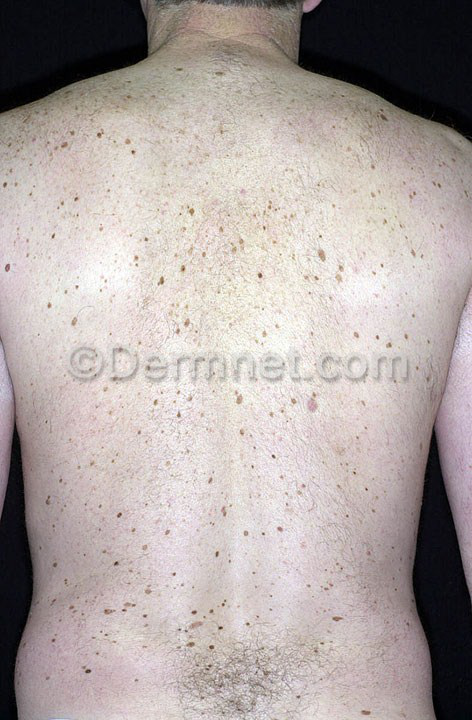

In [4]:
import random
from pathlib import Path
from PIL import Image
random.seed(41)
image_path = Path("skindiseasedataset/SkinDisease/SkinDisease/train")
image_path_list = list(image_path.glob("*/*.*"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(471.5), np.float64(719.5), np.float64(-0.5))

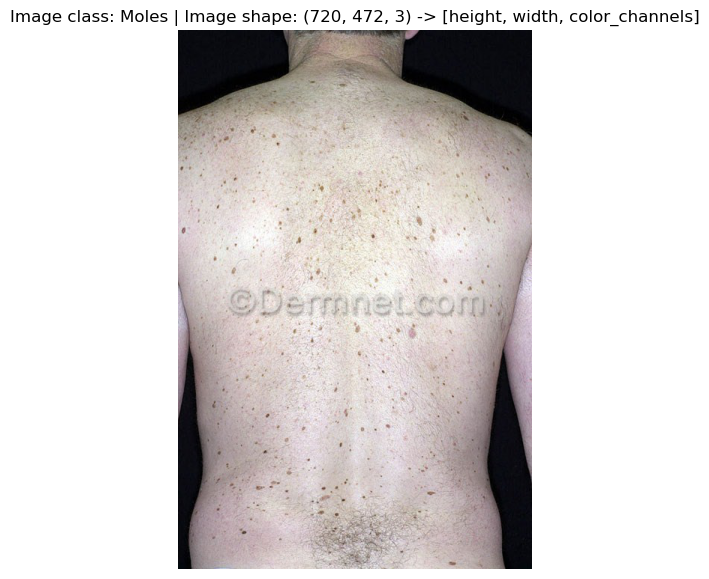

In [5]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
import torchvision.models as models
import torch.nn as nn

weights = models.EfficientNet_B0_Weights.DEFAULT
my_model = models.efficientnet_b0(weights=weights).to(device)

in_features = my_model.classifier[1].in_features

my_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 22)
).to(device)

auto_transforms = weights.transforms()
for param in my_model.features.parameters():#freezing the whole model except the head
    param.requires_grad = False
optimizer = torch.optim.Adam(params=my_model.parameters(), lr=1e-3)

In [ ]:
for param in my_model.features.parameters():#unfreezing the whole model
    param.requires_grad = True
optimizer = torch.optim.Adam(params=my_model.parameters(), lr=1e-5)

In [ ]:
from torchvision import transforms
#For training phase 1 which is only the head, the size we took 224x224
auto_transforms = weights.transforms()
train_transform = transforms.Compose([
    transforms.Resize(auto_transforms.resize_size),
    transforms.CenterCrop(auto_transforms.crop_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=auto_transforms.mean, std=auto_transforms.std)
])
test_transform = auto_transforms

In [ ]:
from torchvision import transforms
#For training phase 2 after unfreezing the whole model
IMAGE_SIZE = 260 

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    # ColorJitter helps the model handle different room lighting/flash
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 13898
    Root location: skindiseasedataset/SkinDisease/SkinDisease/train
    StandardTransform
Transform: Compose(
               Resize(size=(260, 260), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.5)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 1546
    Root location: skindiseasedataset/SkinDisease/SkinDisease/test
    StandardTransform
Transform: Compose(
               Resize(size=(260, 260), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485

In [13]:
class_names = train_data.classes
num_classes = len(class_names)
from collections import Counter
class_counts = Counter(train_data.targets)
total_samples = len(train_data)
weights = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
weights_tensor = torch.FloatTensor(weights).to(device)

In [14]:
class_names = train_data.classes
class_names

['Acne',
 'Actinic_Keratosis',
 'Benign_tumors',
 'Bullous',
 'Candidiasis',
 'DrugEruption',
 'Eczema',
 'Infestations_Bites',
 'Lichen',
 'Lupus',
 'Moles',
 'Psoriasis',
 'Rosacea',
 'Seborrh_Keratoses',
 'SkinCancer',
 'Sun_Sunlight_Damage',
 'Tinea',
 'Unknown_Normal',
 'Vascular_Tumors',
 'Vasculitis',
 'Vitiligo',
 'Warts']

In [ ]:
len(train_data), len(test_data)#number of images in train data and test data

(13898, 1546)

In [16]:
class_dict = train_data.class_to_idx
class_dict

{'Acne': 0,
 'Actinic_Keratosis': 1,
 'Benign_tumors': 2,
 'Bullous': 3,
 'Candidiasis': 4,
 'DrugEruption': 5,
 'Eczema': 6,
 'Infestations_Bites': 7,
 'Lichen': 8,
 'Lupus': 9,
 'Moles': 10,
 'Psoriasis': 11,
 'Rosacea': 12,
 'Seborrh_Keratoses': 13,
 'SkinCancer': 14,
 'Sun_Sunlight_Damage': 15,
 'Tinea': 16,
 'Unknown_Normal': 17,
 'Vascular_Tumors': 18,
 'Vasculitis': 19,
 'Vitiligo': 20,
 'Warts': 21}

In [17]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         ...,
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809]],

        [[-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         ...,
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957]],

        [[-1.6650, -1.6650, -1.6650,  ..., -1.6650, -1.6650, -1.6650],
         [-1.6650, -1.6650, -1.

In [18]:
img_permute = img.permute(1, 2, 0)

In [ ]:
from torch.utils.data import DataLoader
#for phase 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              num_workers=0,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=0,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2eaefeed550>,
 <torch.utils.data.dataloader.DataLoader at 0x2eaeffaaad0>)

In [20]:

img_batch, label_batch = next(iter(train_dataloader))

img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

my_model.eval()
with torch.inference_mode():
    pred = my_model(img_single.to(device))

print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 260, 260])

Output logits:
tensor([[-0.0086, -0.1065,  0.0605,  0.0405,  0.3960, -0.0142, -0.1313, -0.2582,
          0.2575,  0.4931, -0.4776, -0.2211,  0.0063,  0.1030,  0.2990,  0.0737,
         -0.0678,  0.3153,  0.1555, -0.0248, -0.0795,  0.0447]],
       device='cuda:0')

Output prediction probabilities:
tensor([[0.0423, 0.0384, 0.0454, 0.0445, 0.0634, 0.0421, 0.0374, 0.0330, 0.0552,
         0.0699, 0.0265, 0.0342, 0.0430, 0.0473, 0.0576, 0.0460, 0.0399, 0.0585,
         0.0499, 0.0416, 0.0394, 0.0446]], device='cuda:0')

Output prediction label:
tensor([9], device='cuda:0')

Actual label:
5


In [21]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()

    train_loss, train_acc = 0, 0
    total_batches = len(dataloader)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        batch_acc= (y_pred_class == y).sum().item()/len(y_pred)
        train_acc +=batch_acc
        if batch % 100 == 0:
            print(f"Looked at batch {batch}/{total_batches} | Loss: {loss.item():.4f}| Acc: {batch_acc:.4f}", flush=True)
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [22]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(weight=weights_tensor),
          epochs: int = 5):

    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    best_test_acc = 0.0
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        #scheduler.step(test_loss)#for ReduceLROnPlateau scheduler
        scheduler.step()#for CosineAnnealingLR scheduler
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
        if test_acc > best_test_acc:
           best_test_acc = test_acc
           torch.save(my_model.state_dict(), "best_skin_model.pth")
           print(f"--- Saved new best model (Acc: {best_test_acc:.4f}) ---")
    return results

In [ ]:
my_model.load_state_dict(torch.load("best_skin_model.pth"))#for saving the best model after every epoch

<All keys matched successfully>

In [ ]:
#for phase 3 changing resolutions and fine tuning
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NEW_SIZE = 300 

train_transform = transforms.Compose([
    transforms.Resize((320, 320)),       
    transforms.RandomCrop(300),          
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((NEW_SIZE, NEW_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)
#for phase2 and phase 3
#BATCH_SIZE = 32
BATCH_SIZE = 16#to prevent the out of memory problem
train_dataloader = DataLoader(train_data, 
                              batch_size=BATCH_SIZE, 
                              shuffle=True, 
                              num_workers=2, 
                              pin_memory=True)

test_dataloader = DataLoader(test_data, 
                             batch_size=BATCH_SIZE, 
                             shuffle=False, 
                             num_workers=2, 
                             pin_memory=True)

In [ ]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10
#for phase 1
#loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)
#optimizer = torch.optim.Adam(params=my_model.parameters(), lr=1e-5)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=2)

#for phase 2
#loss_fn = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.2)
#optimizer = torch.optim.Adam([
#{'params': my_model.features.parameters(), 'lr': 1e-6},
#{'params': my_model.classifier.parameters(), 'lr': 1e-4}
#],weight_decay=1e-3)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.2,patience=2)

#for phase 3
loss_fn = nn.CrossEntropyLoss( weight=weights_tensor,label_smoothing=0.1)
#optimizer = torch.optim.AdamW(my_model.parameters(), lr=1e-5, weight_decay=1e-2)
optimizer = torch.optim.AdamW([
    {'params': my_model.features.parameters(), 'lr': 1e-7}, 
    {'params': my_model.classifier.parameters(), 'lr': 1e-6}
], weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)





from timeit import default_timer as timer
start_time = timer()

my_model_results = train(model=my_model,train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer=optimizer, loss_fn=loss_fn, epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Looked at batch 0/869 | Loss: 0.9224| Acc: 1.0000
Looked at batch 100/869 | Loss: 0.9864| Acc: 0.8750
Looked at batch 200/869 | Loss: 0.9549| Acc: 1.0000
Looked at batch 300/869 | Loss: 1.2104| Acc: 0.8125
Looked at batch 400/869 | Loss: 0.9477| Acc: 1.0000
Looked at batch 500/869 | Loss: 1.2685| Acc: 0.8750
Looked at batch 600/869 | Loss: 1.0702| Acc: 0.9375
Looked at batch 700/869 | Loss: 0.9914| Acc: 0.9375
Looked at batch 800/869 | Loss: 0.8037| Acc: 1.0000
Epoch: 1 | train_loss: 1.0088 | train_acc: 0.9455 | test_loss: 1.6025 | test_acc: 0.7376
--- Saved new best model (Acc: 0.7376) ---
Looked at batch 0/869 | Loss: 1.0640| Acc: 0.8750
Looked at batch 100/869 | Loss: 1.1136| Acc: 0.9375
Looked at batch 200/869 | Loss: 1.2207| Acc: 0.8750
Looked at batch 300/869 | Loss: 1.0096| Acc: 1.0000
Looked at batch 400/869 | Loss: 0.9050| Acc: 1.0000
Looked at batch 500/869 | Loss: 1.1664| Acc: 0.7500
Looked at batch 600/869 | Loss: 0.8218| Acc: 1.0000
Looked at batch 700/869 | Loss: 1.1108| 

In [ ]:
import torch
my_model.load_state_dict(torch.load('best_skin_model.pth'))
permanent_model_name = 'efficientnet_b0_skin_disease_74_9_acc.pth'
torch.save(my_model.state_dict(), permanent_model_name)

In [28]:
my_model.load_state_dict(torch.load("efficientnet_b0_skin_disease_74_9_acc.pth"))

<All keys matched successfully>

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curves(results):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.legend()

# Call the function after training
plot_loss_curves(my_model_results)#graph is in seperate file

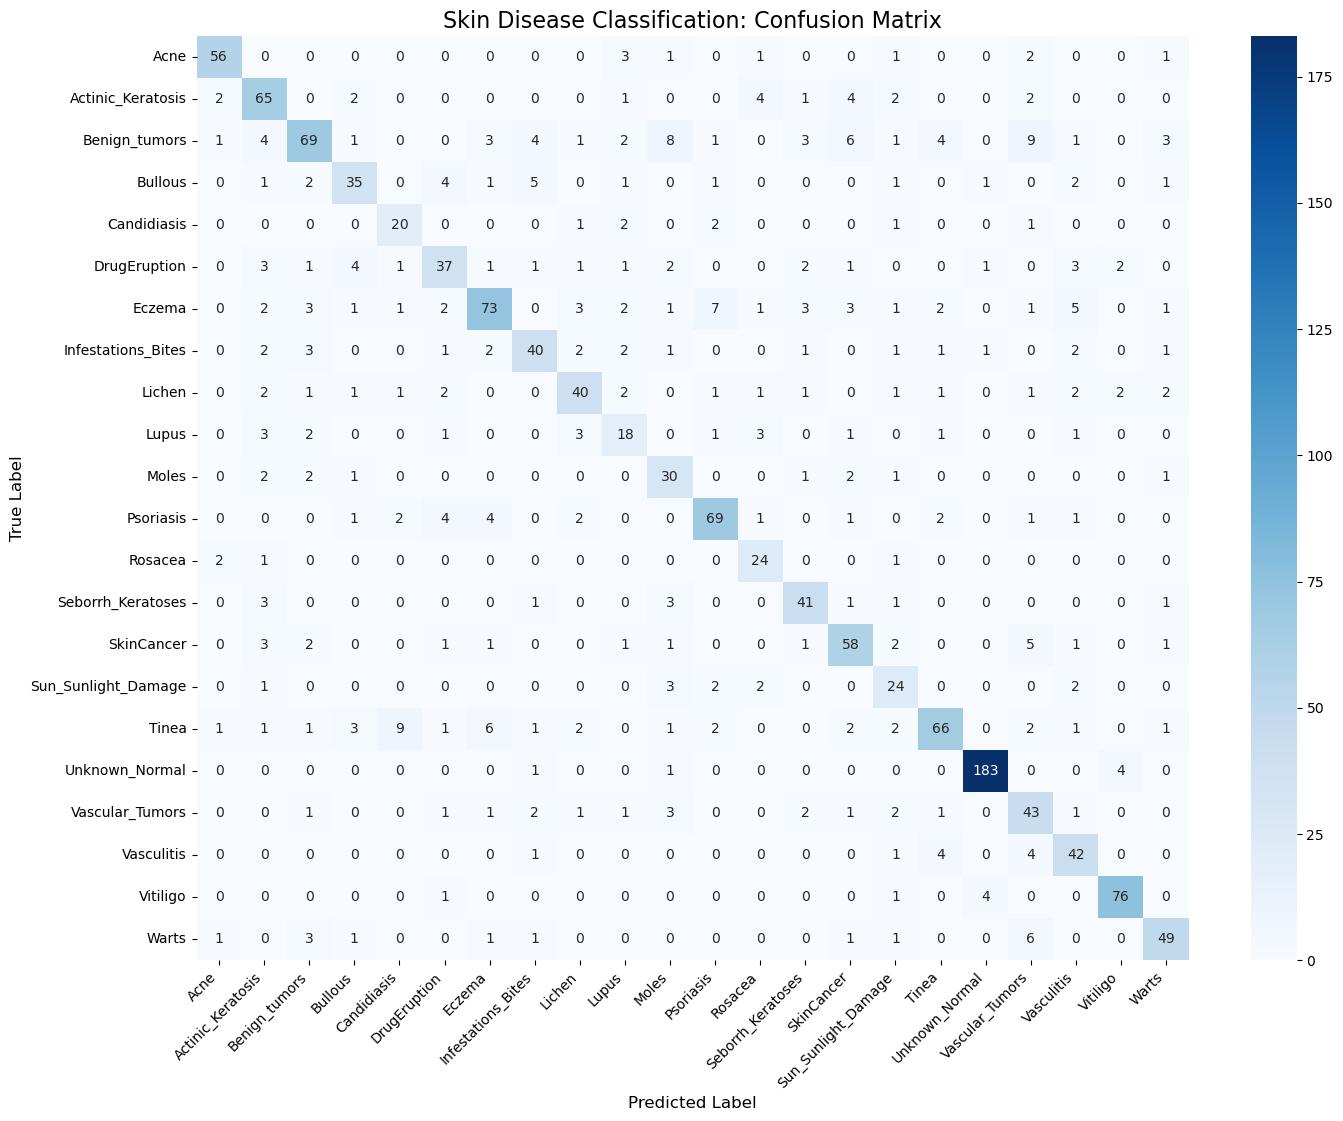

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
#CONFUSION MATRIX
def plot_confusion_matrix(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('Skin Disease Classification: Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

plot_confusion_matrix(my_model, test_dataloader, class_names)

In [31]:
# Check Top-1 and Top-5 accuracy
def final_eval(model, dataloader):
    model.eval()
    top1 = 0
    top5 = 0
    total = 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)

            # Top 1
            _, pred1 = outputs.max(1)
            top1 += pred1.eq(y).sum().item()

            # Top 5
            _, pred5 = outputs.topk(5, 1, True, True)
            top5 += torch.eq(pred5, y.view(-1, 1).expand_as(pred5)).sum().item()

            total += y.size(0)

    print(f"Final Top-1 Accuracy: {100 * top1 / total:.2f}%")
    print(f"Final Top-5 Accuracy: {100 * top5 / total:.2f}%")

final_eval(my_model, test_dataloader)

Final Top-1 Accuracy: 74.90%
Final Top-5 Accuracy: 95.80%


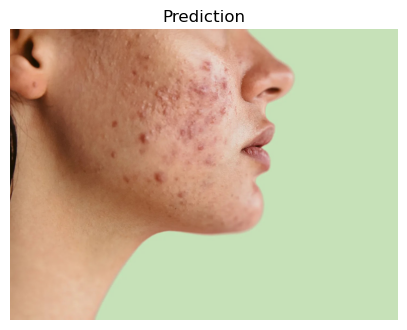

Model's Top 3 Diagnoses:
------------------------------
1. Acne: 95.71% confidence
2. Vitiligo: 0.88% confidence
3. Lupus: 0.52% confidence


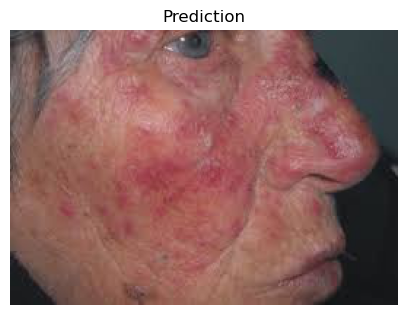

Model's Top 3 Diagnoses:
------------------------------
1. Actinic_Keratosis: 78.25% confidence
2. Rosacea: 18.05% confidence
3. Bullous: 1.42% confidence


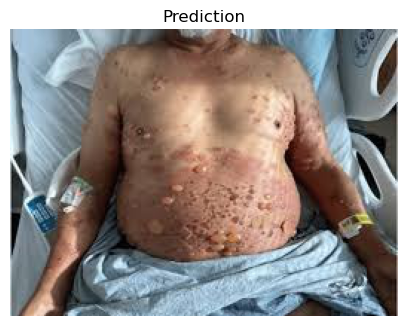

Model's Top 3 Diagnoses:
------------------------------
1. Bullous: 97.73% confidence
2. DrugEruption: 1.06% confidence
3. Moles: 0.33% confidence


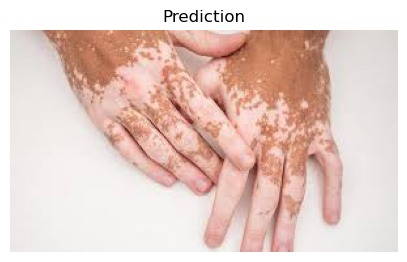

Model's Top 3 Diagnoses:
------------------------------
1. Vitiligo: 89.01% confidence
2. Seborrh_Keratoses: 1.44% confidence
3. Moles: 1.02% confidence


In [35]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

tta_transforms = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_real_image(model, image_path, class_names, num_augmentations=5):
    model.eval()

    try:
        img = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        print(f"❌ Could not find image at {image_path}. Check the file name!")
        return

    augmented_images = [tta_transforms(img) for _ in range(num_augmentations)]

    batch = torch.stack(augmented_images).to(device)

    with torch.inference_mode():
        logits = model(batch)
        probs = torch.softmax(logits, dim=1)
        avg_probs = torch.mean(probs, dim=0)
        top_3_probs, top_3_indices = torch.topk(avg_probs, 3)


    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Prediction")
    plt.show()

    print("Model's Top 3 Diagnoses:")
    print("-" * 30)
    for i in range(3):
        prob = top_3_probs[i].item() * 100
        label = class_names[top_3_indices[i].item()]
        print(f"{i+1}. {label}: {prob:.2f}% confidence")
predict_real_image(my_model, "acne.jpeg", class_names)
predict_real_image(my_model, "actinic_keratosis.jpeg", class_names)
predict_real_image(my_model, "bullous.jpeg", class_names)
predict_real_image(my_model, "vit.jpg", class_names)

In [ ]:
from sklearn.metrics import classification_report

def print_comprehensive_metrics(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.inference_mode():
        for X, y in dataloader:
            X = X.to(device)
            preds = torch.argmax(model(X), dim=1)
            
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    
    print("Clinical Classification Report:")
    print("=" * 60)
    print(report)

print_comprehensive_metrics(my_model, test_dataloader, class_names)

Clinical Classification Report:
                     precision    recall  f1-score   support

               Acne     0.8889    0.8615    0.8750        65
  Actinic_Keratosis     0.6989    0.7831    0.7386        83
      Benign_tumors     0.7667    0.5702    0.6540       121
            Bullous     0.7000    0.6364    0.6667        55
        Candidiasis     0.5882    0.7407    0.6557        27
       DrugEruption     0.6727    0.6066    0.6379        61
             Eczema     0.7849    0.6518    0.7122       112
 Infestations_Bites     0.7018    0.6667    0.6838        60
             Lichen     0.7143    0.6557    0.6838        61
              Lupus     0.5000    0.5294    0.5143        34
              Moles     0.5455    0.7500    0.6316        40
          Psoriasis     0.8023    0.7841    0.7931        88
            Rosacea     0.6486    0.8571    0.7385        28
  Seborrh_Keratoses     0.7321    0.8039    0.7664        51
         SkinCancer     0.7160    0.7532    0.7342  